# Test of the Reciever Simulator


In [7]:
from simulation.observation_handler import ObservationHandler
from simulation.loads import Load
from simulation.receiver import Receiver

import matplotlib.pyplot as plt
import numpy as np
import astropy.units as un

from utils.utils import gamma_db_to_impedence
import os

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams.update({
    "font.family": "serif"
})

Done


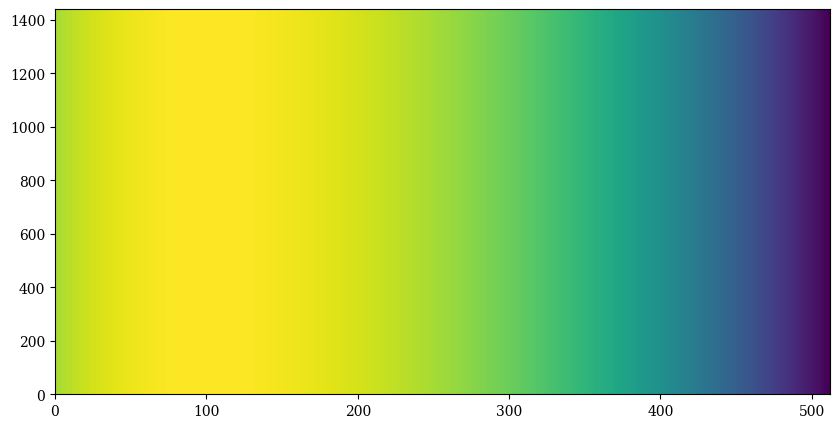

In [ ]:
test_receiver = Receiver(gamma_rec_s2p_path='/Users/user/Desktop/RHINO/new_daq/VNA_Measurements_John/RecBlock/RecBlockSDR0.s2p',
                         gains_s2p_path='/Users/user/Desktop/RHINO/new_daq/VNA_Measurements_John/RecBlock/RecBlock0.s2p',
                         t_unc_scale=300,
                         t_sin_scale=20,
                         t_cos_scale=50,
                         t_0_scale=400)

test_receiver.change_freqs(np.linspace(60*un.MHz, 80*un.MHz, 512))

open_load = Load(physical_temperature=293,
                 label='open',
                 termination_type='open',
                 freqs=test_receiver.freqs)

short_load = Load(physical_temperature=293,
                 label='short',
                 termination_type='short',
                 freqs=test_receiver.freqs)

long_open = Load(physical_temperature=293,
                 label='long_open',
                 termination_type='open',
                 effective_cable_length=3*un.m,
                 freqs=test_receiver.freqs)

long_short = Load(physical_temperature=293,
                 label='long_short',
                 termination_type='short',
                 effective_cable_length=3*un.m,
                 freqs=test_receiver.freqs)

matched_ambient = Load(physical_temperature=293,
                       label='internal_load',
                       termination_type='matched',
                       freqs=test_receiver.freqs)

heated_load = Load(physical_temperature=matched_ambient.t_src+10,
                      label='heated_load',
                      termination_type='matched',
                      freqs=test_receiver.freqs)


matched_ambient = Load(physical_temperature=293,
                termination_impedence=gamma_db_to_impedence(-20),
                freqs=test_receiver.freqs,
                effective_cable_length=0*un.m,
                label='internal_load')

heated_load = Load(physical_temperature=293+150,
                termination_impedence=gamma_db_to_impedence(-20),
                freqs=test_receiver.freqs,
                effective_cable_length=0*un.m,
                label='heated_load')

test_src = Load(physical_temperature=300,
                termination_impedence=100*un.Ohm,
                freqs=test_receiver.freqs,
                effective_cable_length=2*un.m,
                label='antenna')

from simulation.toy_sky import ToySky

test_src = ToySky(physical_temperature=None,
                  termination_impedence=100*un.Ohm,
                  freqs=test_receiver.freqs,
                  effective_cable_length=2*un.m,
                  label='antenna',
                  enr=1,
                  synchrotron_amplitude_210=180,
                  synchrotron_beta=-2.6)
print(len(test_src.t_src))
plt.plot(test_src.freqs, test_src.t_src)
plt.xlabel('Frequency')
plt.ylabel('Temperature')
plt.title('Synchrotron Temperatures')
plt.show()

observation_handler_obj = ObservationHandler(observation_length=1*3600*un.s,
                                             receiver=test_receiver,
                                             sources=[long_open,
                                                      long_short,
                                                      open_load,
                                                      short_load,
                                                      test_src],
                                            dicke_switch_sources=[matched_ambient,
                                                                  heated_load],
                                            dicke_switch_length=150*un.s,
                                            delta_t=5*un.s,
                                            n_t_unc_freq_coeffs=2,
                                            n_t_unc_time_coeffs=2,
                                            n_t_sin_freq_coeffs=2,
                                            n_t_sin_time_coeffs=2,
                                            n_t_cos_freq_coeffs=2,
                                            n_t_cos_time_coeffs=2,
                                            n_gain_freq_coeffs=3,
                                            n_gain_time_coeffs=3,
                                            gain_fluctuation_amp_frac=0.05)

plt.pcolormesh(observation_handler_obj.gains)

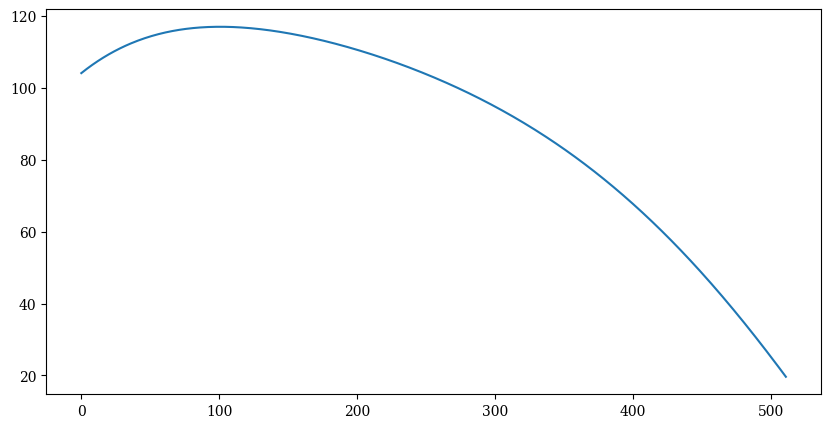

In [18]:
plt.plot(observation_handler_obj.gains.mean(axis=0))

In [19]:
os.makedirs('simulated_data',
          exist_ok=True)

observation_handler_obj.save_to_hdf5(filepath="simulated_data/sim_data.hdf5")
open_load.export_to_s2p('simulated_data')
short_load.export_to_s2p('simulated_data')
long_open.export_to_s2p('simulated_data')
long_short.export_to_s2p('simulated_data')
matched_ambient.export_to_s2p('simulated_data')
heated_load.export_to_s2p('simulated_data')
test_src.export_to_s2p('simulated_data')
test_receiver.export_to_s2p('simulated_data')

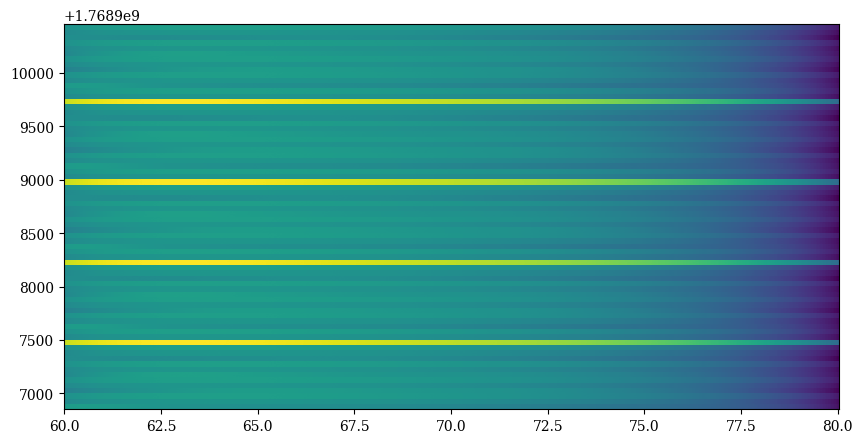

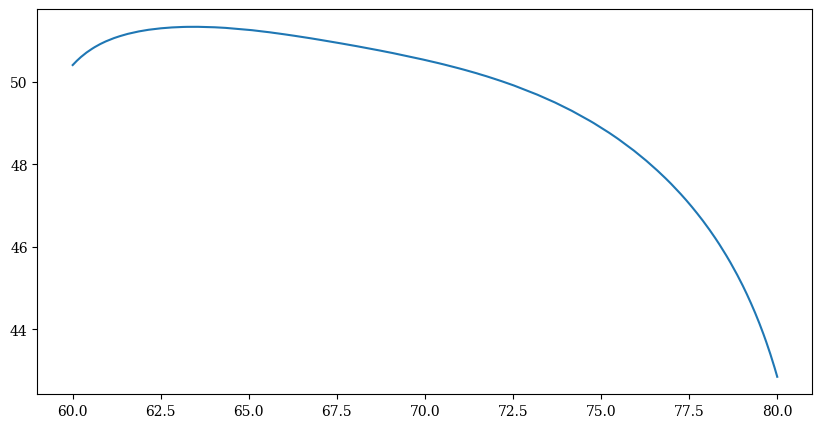

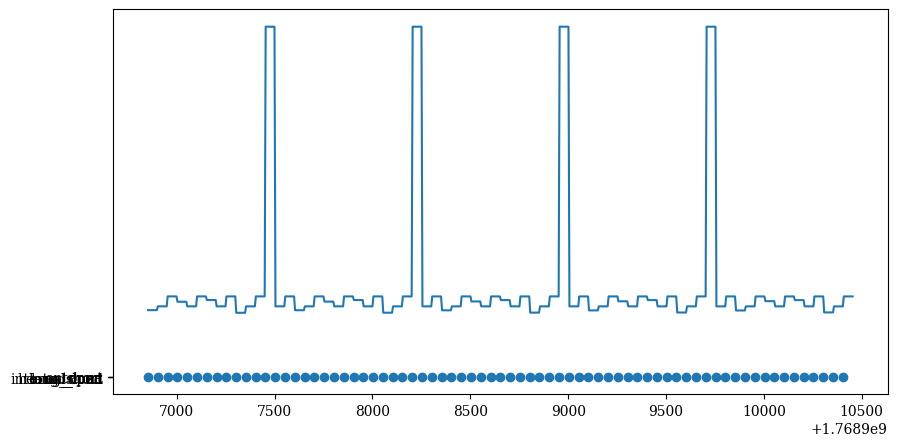

<class 'str'>
<class 'numpy.float64'>
internal_load
[293.11033822 293.24970569 292.8410008  293.07282388 293.02695768
 293.03687589 293.02414599 292.98032795 293.06518728 293.04318064
 292.81663176 292.70516303 292.96960579 292.91611076 292.98947997
 292.9141066  293.27137137 292.84832407 292.96317057 292.93716046
 293.02862874 292.80219605 292.95750597 293.21025222 292.9473163
 292.89311358 292.99729883 293.05773245 292.93731958 293.16133542
 293.07256945 292.9942954  292.97118042 293.10356311 292.9249201
 293.03069211 292.9626972  293.07943874 292.95725294 293.1309034
 293.06696597 293.05692066 292.99684076 293.00096748 292.91711319
 293.14773286 293.02913709 292.81349452 293.0893837  293.00545137
 292.88223179 293.0205628  293.05208753 293.10526295 293.20455078
 293.08350712 293.14375697 292.96754925 292.9285149  292.90042553
 292.89582139 293.09322155 293.05318732 293.12794126 293.14309209
 293.11715107 292.99647984 293.04618287 293.16782473 293.05699243
 292.94876714 293.11026595 

In [6]:

plt.pcolormesh(np.array(observation_handler_obj.freqs),
               np.array(observation_handler_obj.times),
               10*np.log10(observation_handler_obj.data))
plt.show()

plt.plot(observation_handler_obj.freqs,10*np.log10(np.mean(observation_handler_obj.data, axis=0)))
plt.show()

plt.plot(observation_handler_obj.times, observation_handler_obj.data.sum(axis=1))
plt.scatter(observation_handler_obj.switch_times, observation_handler_obj.switch_states)
plt.show()

print(type(observation_handler_obj.switch_states[0]))
print(type(observation_handler_obj.switch_times[0]))


for i, k in observation_handler_obj.temperature_dict.items():
    print(i)
    print(k)
    print('----')


In [ ]:
plt.plot(observation_handler_obj.temperature_dict['heated_load'])
plt.plot(observation_handler_obj.temperature_dict['short'])

In [ ]:
print(observation_handler_obj.data.shape)
print(observation_handler_obj.data)

In [ ]:
print(observation_handler_obj.temperature_dict)

In [ ]:
from gcr.data_processing import create_nw_data_and_covariance_from_raw
from gcr.transfer_matrix_construction import construct_transfer_matrix


data_waterfall, covar_waterfall, final_times, final_states = create_nw_data_and_covariance_from_raw(waterfall=observation_handler_obj.data,
                                                                             times=observation_handler_obj.times,
                                                                             freqs=observation_handler_obj.freqs,
                                                                             switch_times=observation_handler_obj.switch_times,
                                                                             switch_states=observation_handler_obj.switch_states,
                                                                             source_temperatures=observation_handler_obj.temperature_dict,
                                                                             gamma_src_dict=observation_handler_obj.gamma_src_dict,
                                                                             noise_wave_loads=['open',
                                                                                               'short',
                                                                                               'long_open',
                                                                                               'long_short'],
                                                                            internal_load_label='internal_load',
                                                                            noise_source_label='heated_load',
                                                                            switch_buffer=2*un.s,
                                                                            gamma_rec=observation_handler_obj.gamma_rec)


In [ ]:
print(final_states)

In [ ]:
plt.pcolormesh(data_waterfall)
plt.colorbar()
plt.show()

plt.pcolormesh(covar_waterfall)
plt.colorbar()
plt.show()

for l, state in zip(data_waterfall, final_states):
    plt.plot(l, label=state)
plt.legend()
plt.show()



In [ ]:
print(type(final_times[0]))

example_time = 100 *un.day

float_time = float(example_time.to(un.s) / un.s)

print(float_time)

In [ ]:
unc_coeffs_deg = (5,5)
cos_coeffs_deg = (5,5)
sin_coeffs_deg = (5,5)

print(np.array(observation_handler_obj.freqs[0]))
print(type(np.array(observation_handler_obj.freqs[0])))

print(final_times[0])
print(type(np.array(final_times[0])))

transfer_matrix, (freq_norm, time_norm) = construct_transfer_matrix(np.array(observation_handler_obj.freqs),
                                            np.array(final_times),
                                            switch_states_array=final_states,
                                            unc_poly_orders=unc_coeffs_deg,
                                            cos_poly_orders=cos_coeffs_deg,
                                            sin_poly_orders=sin_coeffs_deg,
                                            switch_state_src_gamma_dict=observation_handler_obj.gamma_src_dict,
                                            gamma_rec=observation_handler_obj.gamma_rec,
                                            return_norm_funcs=True)

print(freq_norm)


In [ ]:
plt.matshow(transfer_matrix, aspect='auto', cmap='jet')
plt.show()

In [ ]:
flattened_data = data_waterfall.flatten()

print(flattened_data.shape)
print(transfer_matrix.shape)

t_vec = np.linalg.lstsq(transfer_matrix, flattened_data)[0]


plt.plot(t_vec)


print(t_vec)

In [ ]:
from gcr.basis_construction import reconstruct_surface

In [ ]:
n_t_unc_coeffs = unc_coeffs_deg[0]*unc_coeffs_deg[-1]
n_t_cos_coeffs = cos_coeffs_deg[0]*cos_coeffs_deg[-1]
n_t_sin_coeffs = sin_coeffs_deg[0]*sin_coeffs_deg[-1]


t_unc_coeffs = t_vec[:n_t_unc_coeffs]
t_cos_coeffs = t_vec[n_t_unc_coeffs:n_t_unc_coeffs+n_t_cos_coeffs]
t_sin_coeffs = t_vec[n_t_unc_coeffs+n_t_cos_coeffs:]

print(t_unc_coeffs)
print(t_cos_coeffs)
print(t_sin_coeffs)

In [ ]:

t_unc_surface = reconstruct_surface(x=np.array(observation_handler_obj.freqs),
                                    y=np.array(observation_handler_obj.times),
                                    flat_coeffs=t_unc_coeffs,
                                    n_x_coeffs=unc_coeffs_deg[0],
                                    n_y_coeffs=unc_coeffs_deg[-1],
                                    x_array_norm_func=freq_norm,
                                    y_array_norm_func=time_norm)

t_cos_surface = reconstruct_surface(x=np.array(observation_handler_obj.freqs),
                                    y=np.array(observation_handler_obj.times),
                                    flat_coeffs=t_cos_coeffs,
                                    n_x_coeffs=cos_coeffs_deg[0],
                                    n_y_coeffs=cos_coeffs_deg[-1],
                                    x_array_norm_func=freq_norm,
                                    y_array_norm_func=time_norm)

t_sin_surface = reconstruct_surface(x=np.array(observation_handler_obj.freqs),
                                    y=np.array(observation_handler_obj.times),
                                    flat_coeffs=t_sin_coeffs,
                                    n_x_coeffs=sin_coeffs_deg[0],
                                    n_y_coeffs=sin_coeffs_deg[-1],
                                    x_array_norm_func=freq_norm,
                                    y_array_norm_func=time_norm)


In [ ]:
# Plot Residuals and Reconstructed Surface
fig, axes = plt.subplots(nrows=3,
                         ncols=3,
                         sharex=True,
                         layout='constrained',
                         figsize=(10,8),
                         sharey=True)

resid_vminmax = 1

unc = axes[0,0].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_unc,
                     cmap='plasma')

unc = axes[1,0].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     t_unc_surface,
                     cmap='plasma')

res = axes[2,0].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_unc - t_unc_surface,
                     vmin=-resid_vminmax,
                     vmax=resid_vminmax,
                     cmap='RdBu')

cos = axes[0,1].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_cos,
                     cmap='inferno')

cos = axes[1,1].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     t_cos_surface,
                     cmap='inferno')

res = axes[2,1].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_cos - t_cos_surface,
                     vmin=-resid_vminmax,
                     vmax=resid_vminmax,
                     cmap='RdBu')

sin = axes[0,2].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_sin,
                     cmap='cividis')

sin  = axes[1,2].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     t_sin_surface,
                     cmap='cividis')

res = axes[2,2].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_sin - t_sin_surface,
                     vmin=-resid_vminmax,
                     vmax=resid_vminmax,
                     cmap='RdBu')


axes[0,0].set_ylabel('True')
axes[1,0].set_ylabel('Recovered')


fig.colorbar(res,
             ax=[axes[2,i] for i in range(3)],
             label='Residuals [K]',
             extend='both')

fig.colorbar(unc,
             ax=[axes[i,0] for i in range(2)],
             label=r'$T_{\rm unc}$ [K]')

fig.colorbar(cos,
             ax=[axes[i,1] for i in range(2)],
             label=r'$T_{\rm cos}$ [K]')

fig.colorbar(sin,
             ax=[axes[i,2] for i in range(2)],
             label=r'$T_{\rm sin}$ [K]')

fig.supxlabel(r'$\nu$ [MHz]')
fig.supylabel(r'$t$ [s]')
fig.suptitle('Straight Solution')
plt.show()


In [ ]:
flat_cov = covar_waterfall.flatten()
inv_cov = 1 / flat_cov

from gcr.noise_wave_gcr import construct_gcr_lhs, construct_gcr_rhs
from scipy.sparse.linalg import cg


S_cov = np.abs(t_vec) / 2
S_inv = np.zeros_like(t_vec)# 1/S_cov
S_inv = 1/S_cov #  np.zeros_like(t_vec)# 1/S_cov

lhs = construct_gcr_lhs(transfer_matrix,
                        N_inv_1d=inv_cov,
                        S_inv=S_inv)

rhs = construct_gcr_rhs(d=flattened_data,
                        H_matrix=transfer_matrix,
                        N_inv_1d=inv_cov,
                        S_inv=S_inv,
                        T_nw0=t_vec,
                        omega_d=np.random.normal(loc=0, scale=1, size=flattened_data.shape),
                        omega_t=np.random.normal(loc=0, scale=1, size=t_vec.shape))

gcr_wsol = cg(lhs, rhs, x0=t_vec)[0]


In [ ]:
t_unc_coeffs = gcr_wsol[:n_t_unc_coeffs]
t_cos_coeffs = gcr_wsol[n_t_unc_coeffs:n_t_unc_coeffs+n_t_cos_coeffs]
t_sin_coeffs = gcr_wsol[n_t_unc_coeffs+n_t_cos_coeffs:]

print(t_unc_coeffs)
print(t_cos_coeffs)
print(t_sin_coeffs)


t_unc_surface = reconstruct_surface(x=np.array(observation_handler_obj.freqs),
                                    y=np.array(observation_handler_obj.times),
                                    flat_coeffs=t_unc_coeffs,
                                    n_x_coeffs=unc_coeffs_deg[0],
                                    n_y_coeffs=unc_coeffs_deg[-1],
                                    x_array_norm_func=freq_norm,
                                    y_array_norm_func=time_norm)

t_cos_surface = reconstruct_surface(x=np.array(observation_handler_obj.freqs),
                                    y=np.array(observation_handler_obj.times),
                                    flat_coeffs=t_cos_coeffs,
                                    n_x_coeffs=cos_coeffs_deg[0],
                                    n_y_coeffs=cos_coeffs_deg[-1],
                                    x_array_norm_func=freq_norm,
                                    y_array_norm_func=time_norm)

t_sin_surface = reconstruct_surface(x=np.array(observation_handler_obj.freqs),
                                    y=np.array(observation_handler_obj.times),
                                    flat_coeffs=t_sin_coeffs,
                                    n_x_coeffs=sin_coeffs_deg[0],
                                    n_y_coeffs=sin_coeffs_deg[-1],
                                    x_array_norm_func=freq_norm,
                                    y_array_norm_func=time_norm)


In [ ]:

# Plot Residuals and Reconstructed Surface
fig, axes = plt.subplots(nrows=3,
                         ncols=3,
                         sharex=True,
                         layout='constrained',
                         figsize=(10,8),
                         sharey=True)


unc = axes[0,0].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_unc,
                     cmap='plasma')

unc = axes[1,0].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     t_unc_surface,
                     cmap='plasma')

res = axes[2,0].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_unc - t_unc_surface,
                     vmin=-resid_vminmax,
                     vmax=resid_vminmax,
                     cmap='RdBu')

cos = axes[0,1].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_cos,
                     cmap='inferno')

cos = axes[1,1].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     t_cos_surface,
                     cmap='inferno')

res = axes[2,1].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_cos - t_cos_surface,
                     vmin=-resid_vminmax,
                     vmax=resid_vminmax,
                     cmap='RdBu')

sin = axes[0,2].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_sin,
                     cmap='cividis')

sin  = axes[1,2].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     t_sin_surface,
                     cmap='cividis')

res = axes[2,2].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_sin - t_sin_surface,
                     vmin=-resid_vminmax,
                     vmax=resid_vminmax,
                     cmap='RdBu')


axes[0,0].set_ylabel('True')
axes[1,0].set_ylabel('Recovered')


fig.colorbar(res,
             ax=[axes[2,i] for i in range(3)],
             label='Residuals [K]',
             extend='both')

fig.colorbar(unc,
             ax=[axes[i,0] for i in range(2)],
             label=r'$T_{\rm unc}$ [K]')

fig.colorbar(cos,
             ax=[axes[i,1] for i in range(2)],
             label=r'$T_{\rm cos}$ [K]')

fig.colorbar(sin,
             ax=[axes[i,2] for i in range(2)],
             label=r'$T_{\rm sin}$ [K]')

fig.supxlabel(r'$\nu$ [MHz]')
fig.supylabel(r'$t$ [s]')
fig.suptitle('Weiner Filter Solution + data noise')
plt.show()


In [ ]:
t_vec - gcr_wsol